# Fase 4 - Pré-processamento de Imagens Médicas


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
dataset_path = 'dataset/chest_xray'


In [3]:
for pasta in ['train', 'test', 'val']:
    caminho = os.path.join(dataset_path, pasta)
    print(f'\n{pasta.upper()}')
    for classe in os.listdir(caminho):
        total = len(os.listdir(os.path.join(caminho, classe)))
        print(f'{classe}: {total} imagens')



TRAIN
NORMAL: 1341 imagens
PNEUMONIA: 3875 imagens

TEST
NORMAL: 234 imagens
PNEUMONIA: 390 imagens

VAL
NORMAL: 8 imagens
PNEUMONIA: 8 imagens


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(dataset_path, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(dataset_path, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


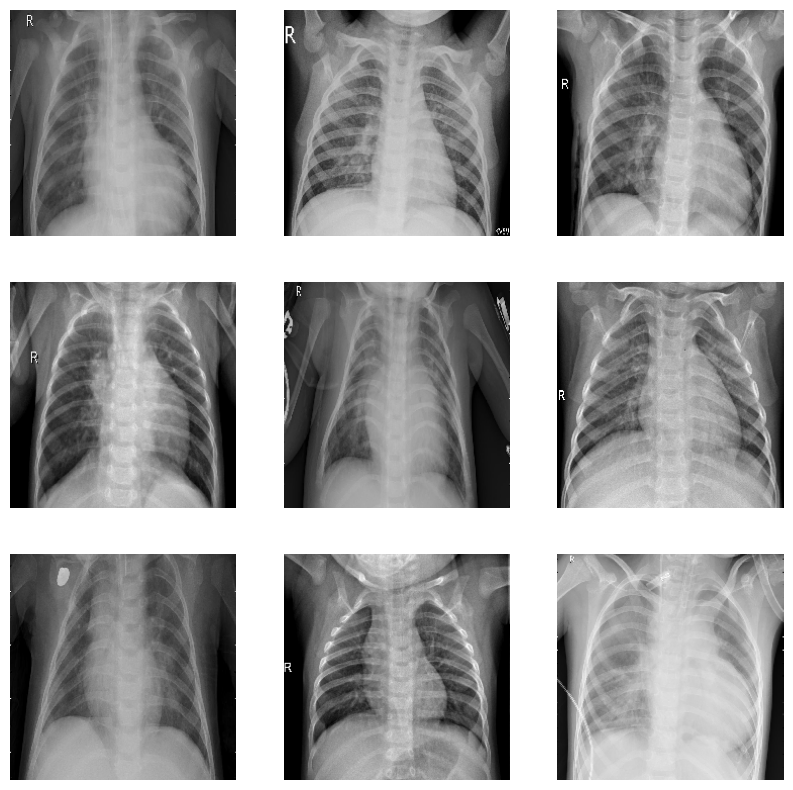

In [5]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()


In [6]:
print(train_generator.class_indices)


{'NORMAL': 0, 'PNEUMONIA': 1}
